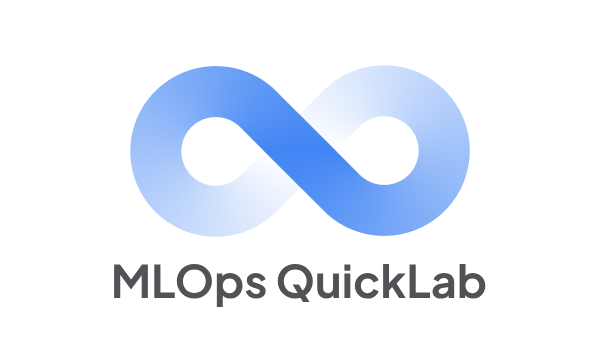

4. Vertex AI 소개 및 개요

In [ ]:
# Cell 1
!pip install datasets torch-model-archiver torch-workflow-archiver transformers


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.7 MB/s eta 0:00:00
  Created wheel for nvgpu: filename=nvgpu-0.10.0-py3-none-any.whl size=9544 sha256=3a81cef11eda10143629c3f753134070b8d7ee0ec1008b69f48f95c9dbdf6d06
  Stored in directory: /root/.cache/pip/wheels/6e/4a/5d/db9b77ea9d1981efbe7a03a10318930d6c5897c85f751d52dc
Successfully built nvgpu


In [ ]:
# Cell 2
!pip install torch-model-archiver

In [ ]:
# Cell 3
# NOTE: model.pth and handler.py are created later in the notebook
# Run this cell AFTER Cell 14 (save model) and Cell 15 (write handler.py)
# Moved to Cell 19 below


WARNING - Overwriting model-store/model.mar ...


In [ ]:
# Cell 4
# Colab-specific: not needed in local environment
# from google.colab import drive
# drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Cell 5
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import seaborn as sns

from torch.utils.data import DataLoader
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification
from sklearn.metrics import confusion_matrix
from datasets import load_dataset
from tqdm import tqdm
from typing import TypedDict
import matplotlib.pyplot as plt

In [ ]:
# Cell 6
dataset = load_dataset("ag_news")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
optimizer = optim.AdamW(model.parameters(), lr=5e-5)
criterion = torch.nn.CrossEntropyLoss()

class DatasetItem(TypedDict):
    text: str
    label: str


def preprocess_data(dataset_item: DatasetItem) -> dict[str, torch.Tensor]:
    return tokenizer(dataset_item["text"], truncation=True, padding="max_length", return_tensors="pt")


train_dataset = dataset["train"].select(range(1200)).map(preprocess_data, batched=True)
test_dataset = dataset["test"].select(range(800)).map(preprocess_data, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
# Cell 7
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 3
losses: list[float] = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}, Average Loss: {average_loss}")

Epoch 1: 100%|██████████| 150/150 [01:46<00:00,  1.41it/s]


Epoch 1, Average Loss: 0.6116005299488704


Epoch 2: 100%|██████████| 150/150 [01:50<00:00,  1.36it/s]


Epoch 2, Average Loss: 0.2793433708883822


Epoch 3: 100%|██████████| 150/150 [01:50<00:00,  1.36it/s]

Epoch 3, Average Loss: 0.1379141069886585


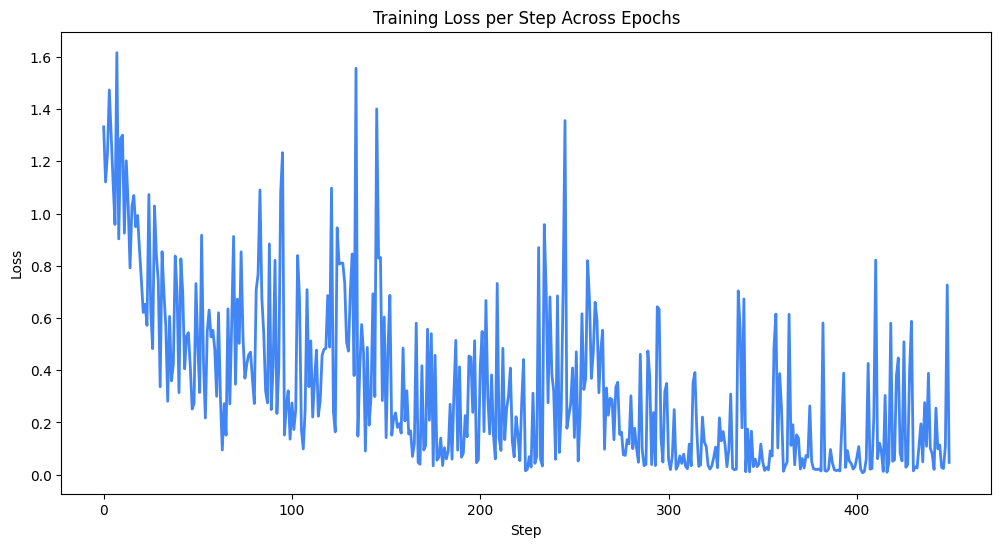

In [ ]:
# Cell 8
plt.figure(figsize=(12, 6))
plt.plot(losses, color="#4285f4", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss per Step Across Epochs")
plt.show()

In [ ]:
# Cell 9
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Evaluating: 100%|██████████| 100/100 [00:22<00:00,  4.42it/s]


Test Accuracy: 79.38%


In [ ]:
# Cell 10
test_input = "[Official] 'Legendary Coach Resigns → Appoints New Commander' Suwon Completes Coaching Staff... Scout Bae Ki-jong Joins + Coach Shin Hwa-yong Remains"
test_input_processed = tokenizer(test_input, truncation=True, padding="max_length", return_tensors="pt").to(device)
logits = model(**test_input_processed).logits
print(logits)
predicted_labels = torch.argmax(logits, dim=1)

labeling_mapper = ["world", "sports", "business", "sci/tech"]
print(labeling_mapper[predicted_labels[0]])

tensor([[ 2.4460, -0.7632, -1.4254, -0.6883]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
world


In [ ]:
# Cell 11
all_predictions: list[int] = []
all_labels: list[int] = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)

        all_predictions.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating: 100%|██████████| 100/100 [00:22<00:00,  4.36it/s]


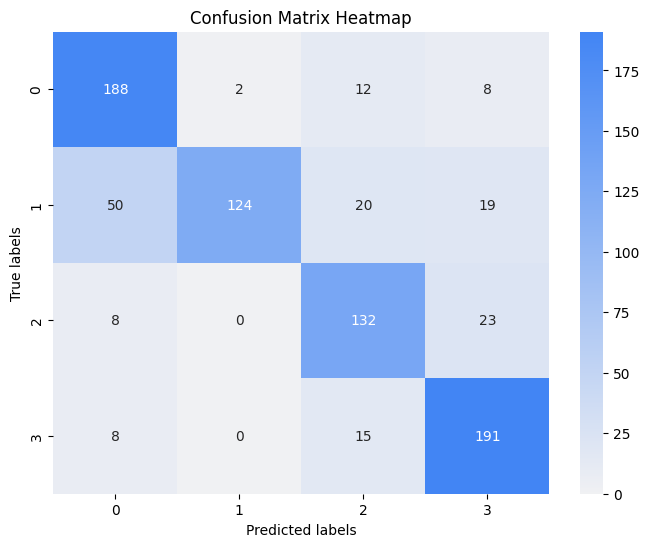

In [ ]:
# Cell 12
conf_matrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap=sns.light_palette("#4285f4", as_cmap=True))
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

## TorchServe Archive

In [ ]:
# Cell 13
# 모델 체크포인트 저장.
model_save_path = "model.pth"
torch.save(model.state_dict(), model_save_path)

In [ ]:
# Cell 14
%%writefile handler.py
import json
import logging

import torch
from ts.context import Context
from ts.torch_handler.base_handler import BaseHandler
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification

logging.basicConfig(level=logging.INFO)

class ModelHandler(BaseHandler):
    def __init__(self):
        self.initialized = False
        self.tokenizer = None
        self.model = None

    def initialize(self, context: Context):
        properties = context.system_properties
        model_dir = properties.get("model_dir")
        self.initialized = True
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
        model_path = model_dir + "/model.pth"
        self.model.load_state_dict(torch.load(model_path))
        self.model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
        self.model.eval()

    def preprocess(self, texts: list[str]) -> BatchEncoding:
        logging.info("preprocess", texts)

        inputs = self.tokenizer(texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
        device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
        return inputs.to(device)

    def inference(self, input_batch: BatchEncoding) -> torch.Tensor:
        with torch.no_grad():
            outputs = self.model(**input_batch)
            logging.info("inference", outputs)
            return outputs.logits

    def postprocess(self, inference_output: torch.Tensor) -> list[dict[str, float]]:
        logging.info("postprocess", inference_output)

        probabilities = torch.nn.functional.softmax(inference_output, dim=1)
        return [{"label": int(torch.argmax(prob)), "probability": float(prob.max())} for prob in probabilities]

Writing handler.py


In [ ]:
# Cell 15
# bert vocab 파일 (아티팩트)

!wget https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt \
    -O bert-base-uncased-vocab.txt

--2026-04-21 06:37:10--  https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231508 (226K) [text/plain]
Saving to: ‘bert-base-uncased-vocab.txt’

bert-base-uncased-v 100%[===================>] 226.08K  --.-KB/s    in 0.01s   

2026-04-21 06:37:10 (17.0 MB/s) - ‘bert-base-uncased-vocab.txt’ saved [231508/231508]



In [ ]:
# Cell 16
# Torch serve archiver의 최종 파일 저장 위치.
# .mar 확장자 파일을 생성하여 패키징 하게 된다.

!mkdir -p model-store

## Register to Vertex AI

In [ ]:
# Cell 17
!python3 -m torch_model_archiver \
    --model-name model \
    --version 1.0 \
    --serialized-file model.pth \
    --handler ./handler.py \
    --extra-files "bert-base-uncased-vocab.txt" \
    --export-path model-store \
    -f

/usr/bin/python3: No module named torch_model_archiver


In [ ]:
# Cell 18
# from google.colab import auth
# auth.authenticate_user()

In [ ]:
# Cell 19
from google.cloud import storage
from google.cloud import aiplatform
from google.oauth2 import service_account

In [ ]:
# Cell 20
credentials = service_account.Credentials.from_service_account_file("moonlit-dynamo-492711-n6-39ee9b54e920.json")

In [ ]:
# Cell 21
PROJECT_ID = "moonlit-dynamo-492711-n6"                    # @param {type: "string"}
LOCATION = "asia-northeast3"                                       # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab-1"   # @param {type: "string"}
MODEL_FILE_NAME = "model.mar"              # @param {type: "string"}

In [ ]:
# Cell 22
storage_client = storage.Client(credentials=credentials)
bucket = storage_client.bucket(BUCKET_NAME)

In [ ]:
# Cell 23
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [ ]:
# Cell 24
upload_blob("model-store/model.mar", f"models/{MODEL_FILE_NAME}")

File model-store/model.mar uploaded to models/model.mar.


### `torch-model-archiver` 설치 확인

In [ ]:
# Cell 25
!which torch-model-archiver
!torch-model-archiver --version

/usr/local/bin/torch-model-archiver
usage: torch-model-archiver [-h] --model-name MODEL_NAME
                            [--serialized-file SERIALIZED_FILE]
                            [--model-file MODEL_FILE] --handler HANDLER
                            [--extra-files EXTRA_FILES]
                            [--runtime {python,python3,LSP}]
                            [--export-path EXPORT_PATH]
                            [--archive-format {tgz,no-archive,zip-store,default}]
                            [-f] -v VERSION [-r REQUIREMENTS_FILE]
                            [-c CONFIG_FILE]
torch-model-archiver: error: argument -v/--version: expected one argument


In [ ]:
# Cell 26
!ls -l model-store/

total 0


In [ ]:
# Cell 27
aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
    credentials=credentials,
)

In [ ]:
# Cell 28
model_path = f"gs://{BUCKET_NAME}/models"
registry_model = aiplatform.Model.upload(
    display_name="AG News Classification",
    artifact_uri=model_path,
    serving_container_image_uri="asia-northeast3-docker.pkg.dev/gde-project-aicloud/mlops-quicklab/trainer:1.0.3",
    is_default_version=True,
    version_aliases=["v1"],
    version_description="A news category classification model",
    serving_container_predict_route="/predictions/model",
    serving_container_health_route="/ping",
)

INFO:google.cloud.aiplatform.models:Creating Model
INFO:google.cloud.aiplatform.models:Create Model backing LRO: projects/634821526652/locations/asia-northeast3/models/351848118934831104/operations/6725966614291808256
INFO:google.cloud.aiplatform.models:Model created. Resource name: projects/634821526652/locations/asia-northeast3/models/351848118934831104@1
INFO:google.cloud.aiplatform.models:To use this Model in another session:
INFO:google.cloud.aiplatform.models:model = aiplatform.Model('projects/634821526652/locations/asia-northeast3/models/351848118934831104@1')


In [ ]:
# Cell 29
DEPLOY_COMPUTE = "n1-standard-2"
DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

In [ ]:
# Cell 30
endpoint = aiplatform.Endpoint.create(
    display_name="ag-news-category-classification",
    project=PROJECT_ID,
    location=LOCATION,
)

INFO:google.cloud.aiplatform.models:Creating Endpoint
INFO:google.cloud.aiplatform.models:Create Endpoint backing LRO: projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016/operations/7552377145914294272


In [ ]:
# Cell 31
deployment = registry_model.deploy(
    endpoint=endpoint,
    machine_type=DEPLOY_COMPUTE,
    min_replica_count=1,
    max_replica_count=1,
    accelerator_type=DEPLOY_ACCELERATOR,
    accelerator_count=1,
    traffic_percentage=100,
    sync=True,
)

INFO:google.cloud.aiplatform.models:Deploying model to Endpoint : projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016
INFO:google.cloud.aiplatform.models:Deploy Endpoint model backing LRO: projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016/operations/4420123605078114304
INFO:google.cloud.aiplatform.models:Endpoint model deployed. Resource name: projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016


In [ ]:
# Cell 32
endpoint.predict(instances=[
    "OpenAI releases AI video generator Sora to all customers"
])

Prediction(predictions=[{'label': 3.0, 'probability': 0.9921878576278687}], deployed_model_id='7880257010875236352', metadata=None, model_version_id='1', model_resource_name='projects/634821526652/locations/asia-northeast3/models/351848118934831104', explanations=None)

## Clean up

In [ ]:
# Cell 33
endpoint.undeploy_all()
endpoint.delete()

INFO:google.cloud.aiplatform.models:Undeploying Endpoint model: projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016
INFO:google.cloud.aiplatform.models:Undeploy Endpoint model backing LRO: projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016/operations/1296877263496675328
INFO:google.cloud.aiplatform.models:Endpoint model undeployed. Resource name: projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016
INFO:google.cloud.aiplatform.base:Deleting Endpoint : projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016
INFO:google.cloud.aiplatform.base:Endpoint deleted. . Resource name: projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016
INFO:google.cloud.aiplatform.base:Deleting Endpoint resource: projects/634821526652/locations/asia-northeast3/endpoints/96884566593110016
INFO:google.cloud.aiplatform.base:Delete Endpoint backing LRO: projects/634821526652/locations/asia-northeast3/op

In [ ]:
# Cell 34
registry_model.delete()

INFO:google.cloud.aiplatform.base:Deleting Model : projects/634821526652/locations/asia-northeast3/models/351848118934831104
INFO:google.cloud.aiplatform.base:Model deleted. . Resource name: projects/634821526652/locations/asia-northeast3/models/351848118934831104
INFO:google.cloud.aiplatform.base:Deleting Model resource: projects/634821526652/locations/asia-northeast3/models/351848118934831104
INFO:google.cloud.aiplatform.base:Delete Model backing LRO: projects/634821526652/locations/asia-northeast3/models/351848118934831104/operations/4570994192595025920
INFO:google.cloud.aiplatform.base:Model resource projects/634821526652/locations/asia-northeast3/models/351848118934831104 deleted.


In [ ]:
# Cell 35
